# GMM (KMeans와 비교 필요)

In [1]:
# 필요한 기능들
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy import stats
import pandas as pd
import numpy as np
from matplotlib import rc

# 경고 메세지 무시
import os
import warnings
warnings.simplefilter(action='ignore', category = FutureWarning)

# 한글 안 깨지게 하기
if os.name == 'nt' :
    font_family = "Malgun Gothic"
else :
    font_family = "AppleGothic"

sns.set(font = font_family, rc = {"axes.unicode_minus" : False})


# csv 파일 가져오기
df = pd.read_csv('data/정제데이터/구별데이터_스케일링.csv', encoding='cp949')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   시군구         25 non-null     object 
 1   기초수급자_인구밀도  25 non-null     float64
 2   저소득층_비율     25 non-null     float64
 3   총생활인구       25 non-null     float64
 4   초미세먼지       25 non-null     float64
 5   미세먼지        25 non-null     float64
 6   인당녹지면적      25 non-null     float64
 7   총공시지가평균     25 non-null     float64
 8   평균기온(°C)    25 non-null     float64
 9   도시재생사업수     25 non-null     float64
dtypes: float64(9), object(1)
memory usage: 2.1+ KB


# 환경불평등지수
- 기초수급자_인구밀도 + (1-인당녹지면적)

In [3]:
df['환경불평등지수'] = df.기초수급자_인구밀도 + (1- df.인당녹지면적)

In [4]:
df.head(3)

,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수
0,강남구,0.258356,0.891770,1.000000,0.50,0.285714,0.827140,1.000000,0.606061,0.0,0.431216
1,강동구,0.518524,0.461778,0.601108,0.75,0.571429,0.715354,0.259889,0.525253,0.4,0.803171
2,강북구,1.000000,0.241271,0.141629,0.25,0.571429,0.501950,0.066923,0.565657,0.6,1.498050


In [5]:
data = df[['총공시지가평균','환경불평등지수']]

In [6]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

mpl.rc('font', family='NanumGothic') # 폰트 설정
mpl.rc('axes', unicode_minus=False) # 유니코드에서 음수 부호 설정

# 차트 스타일 설정
sns.set(font="NanumGothic", rc={"axes.unicode_minus":False}, style='darkgrid')
plt.rc("figure", figsize=(10,8))

warnings.filterwarnings("ignore")

In [7]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):
    if iscenter :
        centers = clusterobj.cluster_centers_
        
    unique_labels = np.unique(dataframe[label_name].values)
    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name]==label]
        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else :
            cluster_legend = 'Cluster '+str(label)
        
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,\
                    edgecolor='k', marker=markers[label], label=cluster_legend)
        
        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)
    if isNoise:
        legend_loc='upper center'
    else: legend_loc='upper right'
    
    plt.legend(loc=legend_loc)
    plt.show()

In [8]:
def gaussian_mixture_clustering(X, n_components, init_mu=None, init_cov_mat=None, init_weights=None,
                                epsilon=1e-4, max_iter=20, random_state=100):
    from scipy.stats import multivariate_normal
    import random
    # set initial value
    if init_mu is None:
        random.seed(random_state)
        idx = random.sample(range(X.shape[0]), n_components)
        mu = X[idx,:]
    else:
        mu = init_mu
 
    if init_cov_mat is None:
        np.random.seed(random_state)
        cov_list = []
        for _ in range(n_components):
            arr = np.random.rand(X.shape[1]**2)+0.1
            temp_mat = np.triu(arr.reshape(X.shape[1], X.shape[1]))
            cov_elem = temp_mat.dot(temp_mat.T)
            cov_list.append(cov_elem)
 
        cov_mat = np.array(cov_list)
    else:
        cov_mat = init_cov_mat
 
    if init_weights is None:
        weights = np.array([1/n_components]*n_components)
    else:
        weights = init_weights
 
    objective_value = -np.infty
    objective_value_history = []
    iteration = 1
    while(iteration<max_iter):
        # E-step
        assign_prob = []
        for i,d in enumerate(X):
            assign_prob_temp = []
            for k in range(n_components):
 
                assign_prob_temp.append(weights[k]*\
                                multivariate_normal(mean=mu[k],cov=cov_mat[k]).pdf(d))
 
            assign_prob_temp = np.array(assign_prob_temp)
            assign_prob_temp = assign_prob_temp/np.sum(assign_prob_temp)
            assign_prob.append(assign_prob_temp)
 
        assign_prob = np.array(assign_prob)
 
        # M-step
        temp_sum = np.sum(assign_prob, axis=0)
        next_weights = []
        next_mu = []
        next_cov_mat = []
        for k in range(n_components):
            mu_numerator = np.sum(np.expand_dims(assign_prob[:,k],axis=1)*X, axis=0)
            next_mu_vector = mu_numerator/temp_sum[k]
            next_mu.append(next_mu_vector)
            next_weights.append(temp_sum[k]/X.shape[0])
 
            t = []
            for i,d in enumerate(X):
                tt = d-next_mu_vector
                tt = np.expand_dims(tt,axis=1)
                tt_cov = np.matmul(tt,tt.transpose())
                tt_term = assign_prob[i][k]*tt_cov
                t.append(tt_term)
            t = np.array(t)
            cov_numerator = np.sum(t,axis=0)
            next_cov_mat.append(cov_numerator/temp_sum[k])
 
        next_objective_value = 0
        for x in X:
            value = np.log(np.sum([next_weights[k]*multivariate_normal(mean=next_mu[k],cov=next_cov_mat[k]).pdf(x) 
                     for k in range(n_components)]))
            next_objective_value += value
        objective_value_history.append(next_objective_value)
        if next_objective_value-objective_value<=epsilon:
            labels = [np.argmax(x) for x in assign_prob]
            return (labels, iteration, objective_value_history)
        else:
            weights = next_weights
            mu = next_mu
            cov_mat = next_cov_mat
            objective_value = next_objective_value
        iteration += 1
    labels = [np.argmax(x) for x in assign_prob]
    return (labels, iteration, objective_value_history)

In [9]:
gmm = GaussianMixture(n_components = 3, random_state = 0)
df['cluster'] = gmm.fit_predict(data)

Gulim


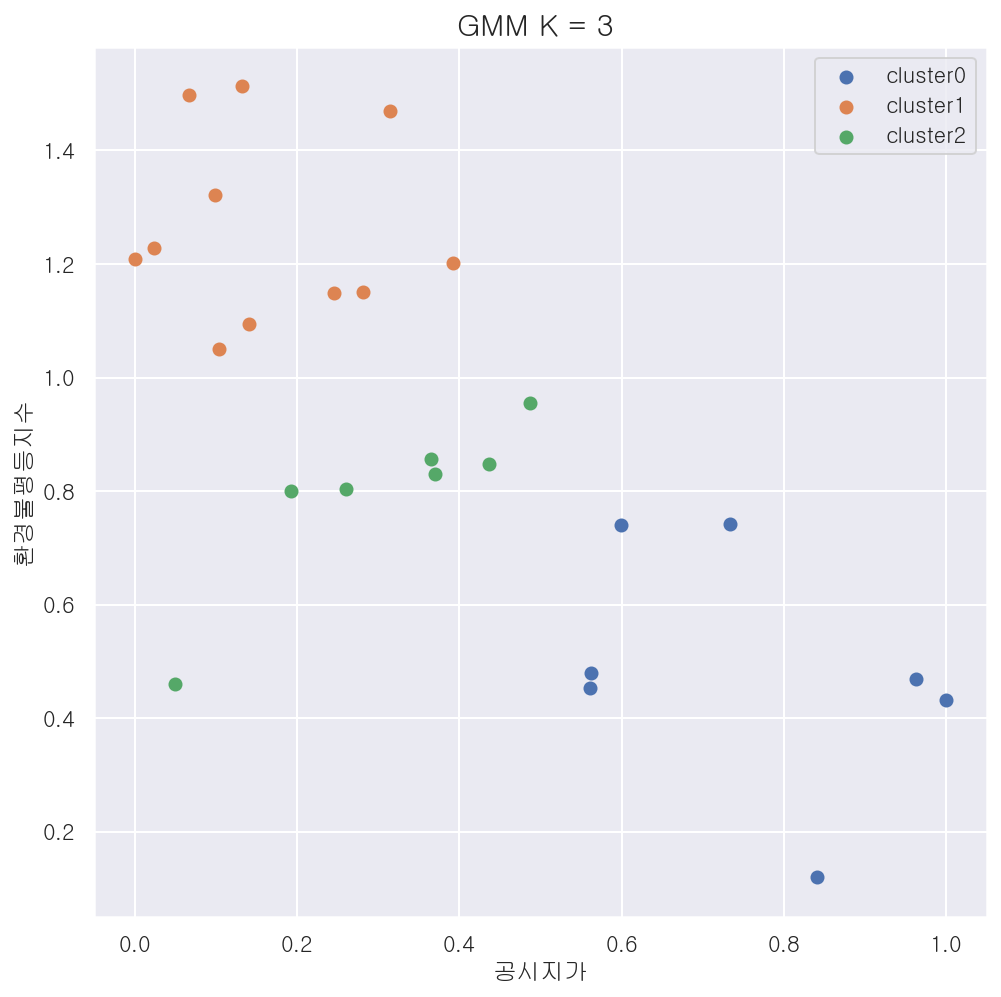

In [15]:
import matplotlib.pyplot as plt

k=3

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(df.loc[df['cluster'] == i, '총공시지가평균'], df.loc[df['cluster'] == i, '환경불평등지수'], label = 'cluster' + str(i))

plt.legend()
plt.title('GMM K = %d '%k , size = 15)
plt.xlabel('공시지가', size = 12)
plt.ylabel('환경불평등지수', size = 12)
plt.show()

In [16]:
cluster_cnt = df.groupby('cluster').agg({'시군구':'count'}).reset_index()
cluster_des = df.groupby('cluster').mean().reset_index()

In [17]:
a = pd.merge(cluster_cnt,cluster_des)

In [18]:
a

,cluster,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수
0,0,7,0.240937,0.364592,0.464322,0.464286,0.489796,0.750309,0.751405,0.506494,0.285714,0.490628
1,1,11,0.738463,0.332974,0.269569,0.522727,0.441558,0.476325,0.163785,0.475666,0.409091,1.262138
2,2,7,0.448484,0.421523,0.452678,0.571429,0.530612,0.655338,0.308722,0.542569,0.385714,0.793146


In [ ]:
import dataframe_image as dfi

dfi.export(a, './image/10-3구별_GMM_describe.png', max_cols = -1, max_rows = -1)

In [13]:
df[df.cluster==1].시군구.unique()

array(['강북구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '양천구',
       '은평구', '중랑구'], dtype=object)

# K-Means랑 결과 같음